Full Code (scikit-learn + TensorFlow)

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load your cleaned data
df = pd.read_csv('clean_data.csv')

# Feature Engineering
df['date_clean'] = pd.to_datetime(df['date_clean'])
df['day_of_week'] = df['date_clean'].dt.dayofweek
df['month'] = df['date_clean'].dt.month
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

# Drop unnecessary columns
X = df.drop(['amount', 'date', 'description', 'notes', 'date_clean'], axis=1)
y = df['amount']

# Define categorical and numerical columns
categorical_cols = ['category', 'payment_method']
numerical_cols = ['day_of_week', 'month', 'is_weekend']

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# ==================== 1. Scikit-learn Model (Random Forest) ====================
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("Random Forest Results:")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f} Rs")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")

Random Forest Results:
Mean Absolute Error: 1049.46 Rs
R² Score: 0.1213


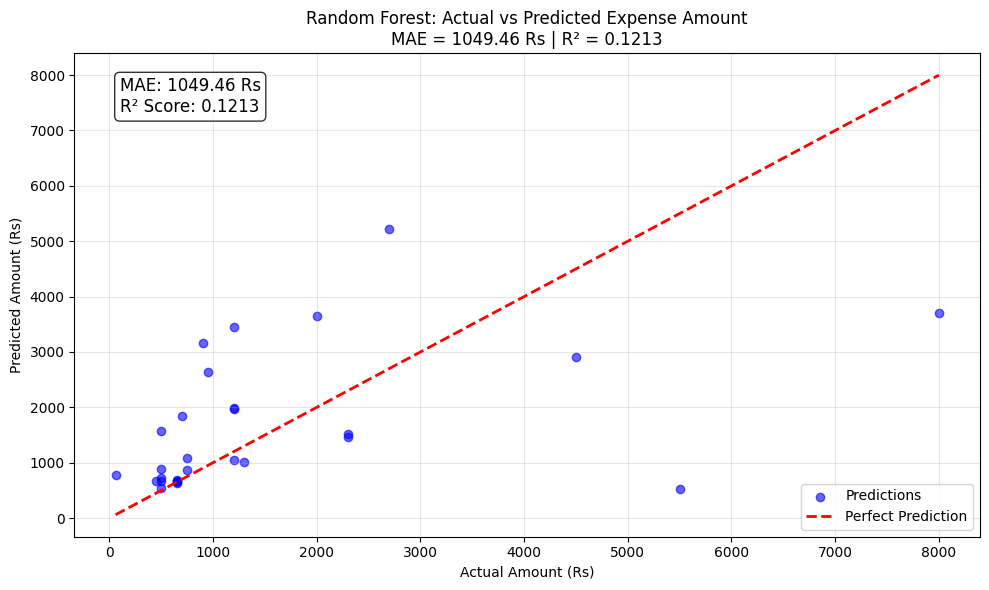

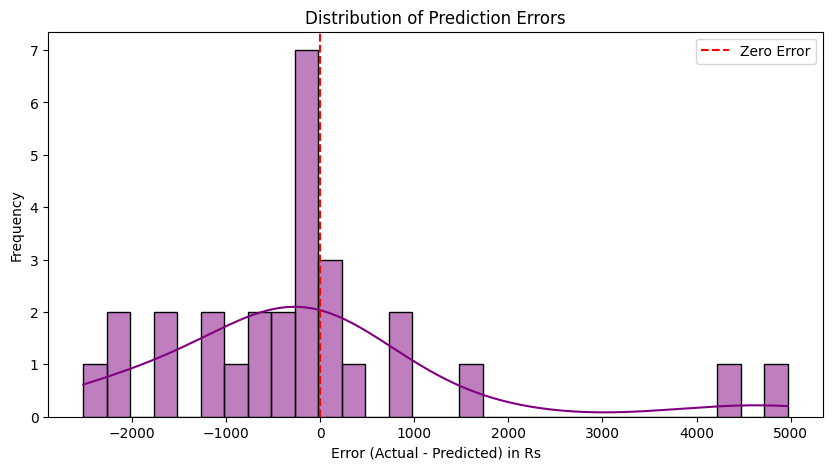

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==================== VISUALIZATION ====================

plt.figure(figsize=(10, 6))

# Scatter plot: Actual vs Predicted
plt.scatter(y_test, y_pred, alpha=0.6, color='blue', label='Predictions')

# Perfect prediction line (y = x)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Amount (Rs)')
plt.ylabel('Predicted Amount (Rs)')
plt.title('Random Forest: Actual vs Predicted Expense Amount\nMAE = 1049.46 Rs | R² = 0.1213')
plt.legend()
plt.grid(True, alpha=0.3)

# Add text with results
plt.text(0.05, 0.95, f'MAE: 1049.46 Rs\nR² Score: 0.1213', 
         transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

# Error Distribution
errors = y_test - y_pred

plt.figure(figsize=(10, 5))
sns.histplot(errors, kde=True, bins=30, color='purple')
plt.title('Distribution of Prediction Errors')
plt.xlabel('Error (Actual - Predicted) in Rs')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--', label='Zero Error')
plt.legend()
plt.show()

TensorFlow / Keras Neural Network Version

In [11]:
from tensorflow import keras
from tensorflow.keras import layers


# Preprocess data for Keras
X_processed =  preprocessor.fit_transform(X)
# Train-test split again on processed data
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

model = keras.Sequential([
    layers.Dense(64,activation='relu',input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam',loss='mae',metrics=['mae'])

#train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=16,
    verbose=1,
    callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
)
loss = model.evaluate(X_test, y_test)
print(f"Test MAE: {loss[1]:.2f} Rs")

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - loss: 1809.3843 - mae: 1809.3843 - val_loss: 2499.9946 - val_mae: 2499.9946
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 1809.2488 - mae: 1809.2488 - val_loss: 2499.8967 - val_mae: 2499.8967
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1809.1075 - mae: 1809.1075 - val_loss: 2499.7466 - val_mae: 2499.7466
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1808.9194 - mae: 1808.9194 - val_loss: 2499.5171 - val_mae: 2499.5171
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step - loss: 1808.6097 - mae: 1808.6097 - val_loss: 2499.2256 - val_mae: 2499.2256
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 1808.3046 - mae: 1808.3046 - val_loss: 2498.8499 - val_mae: 2498.8499
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 1807.8319 - mae: 1807.8319 - val_loss: 2498.3770 - val_mae: 2498.3770
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1807.3550 - mae: 1807.3550 - val_loss: 2497.7554 - v

In [18]:
import pandas as pd
import joblib

# Load the saved model
model = joblib.load('expense_predictor_model.pkl')

# ==================== Make a New Prediction ====================

new_expense = pd.DataFrame({
    'category': ['Food'],           # ← Change this to test
    'payment_method': ['UPI'],      # ← Change this
    'day_of_week': [4],             # 0=Monday ... 6=Sunday
    'month': [3],                   # 1=Jan, 2=Feb, 3=March...
    'is_weekend': [0]               # 1=Weekend, 0=Weekday
})

# Predict
predicted = model.predict(new_expense)[0]

print(f"Predicted expense amount: ₹{predicted:.2f}")

# ==================== Simple Recommendation ====================

print("--- 💡 Smart Recommendation ---")

category = new_expense['category'].iloc[0]

if predicted > 2000:
    print("⚠️ This is a HIGH expense. Think twice before spending.")
elif predicted < 600:
    print("✅ This looks like a small/normal expense. Good!")
else:
    print("✅ This is in normal spending range.")

# Category-wise Tips
if category == 'Food':
    print("🍔 Food is your most repeated category.")
    print("💡 Tip: Try cooking at home 2-3 times a week. You can easily save ₹1000-2000 per month.")

elif category == 'Transport':
    print("🚗 Transport spending detected.")
    print("💡 Tip: Pool rides or use public transport when possible.")

elif category == 'Shopping':
    print("🛍️ Shopping expense.")
    print("💡 Tip: Make a list before shopping to avoid impulse buys.")

else:
    print("📌 Keep tracking this category.")

# ==================== Monthly Food Budget Tracker ====================

# Load your full data to calculate real statistics
df = pd.read_csv('clean_data.csv')   # Change filename if needed
df['date_clean'] = pd.to_datetime(df['date_clean'])

# Calculate Food spending
food_spent = df[df['category'] == 'Food']['amount'].sum()
total_months = df['date_clean'].dt.to_period('M').nunique()
avg_monthly_food = food_spent / total_months if total_months > 0 else 0

print("\n--- 📊 Your Food Spending Insight ---")
print(f"Total Food spent till now : ₹{food_spent:.0f}")
print(f"Average monthly Food expense : ₹{avg_monthly_food:.0f}")

# Simple Budget Recommendation
if avg_monthly_food > 8000:
    print("⚠️ Your average Food spending is quite high.")
    print("Suggested monthly Food budget: ₹6000 - ₹7000")
elif avg_monthly_food > 5000:
    print("Suggested monthly Food budget: ₹4500 - ₹5500")
else:
    print("✅ Your Food spending is under control.")
    print("Suggested monthly Food budget: ₹4000 - ₹5000")

print("\nTip: Try to stay under your suggested budget to save money.")

Predicted expense amount: ₹1254.50
--- 💡 Smart Recommendation ---
✅ This is in normal spending range.
🍔 Food is your most repeated category.
💡 Tip: Try cooking at home 2-3 times a week. You can easily save ₹1000-2000 per month.

--- 📊 Your Food Spending Insight ---
Total Food spent till now : ₹63150
Average monthly Food expense : ₹12630
⚠️ Your average Food spending is quite high.
Suggested monthly Food budget: ₹6000 - ₹7000

Tip: Try to stay under your suggested budget to save money.


📅 Monthly Total Expense Predictor
Average Monthly Expense : ₹50976
Last Month Expense      : ₹84600
Predicted Next Month    : ₹48427


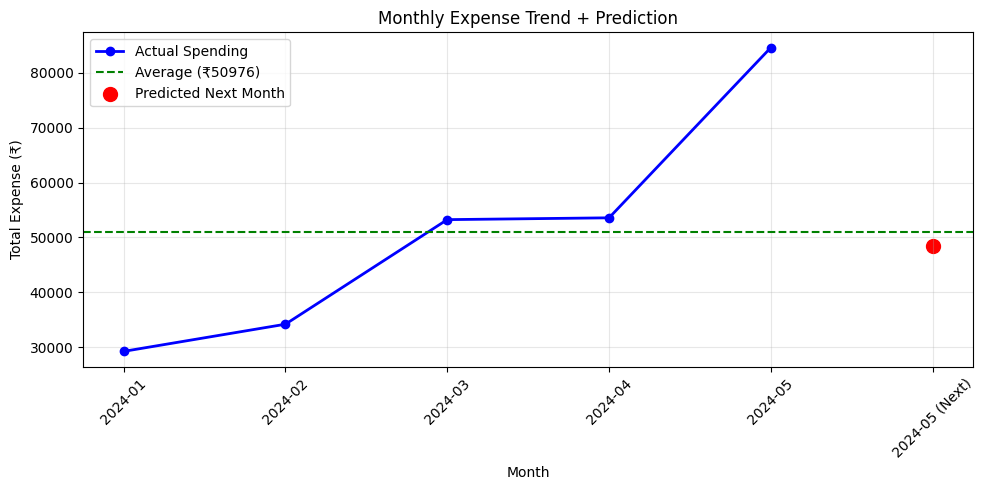

In [19]:
print("📅 Monthly Total Expense Predictor")



# Group by month
monthly_expense = df.groupby(df['date_clean'].dt.to_period('M'))['amount'].sum().reset_index()
monthly_expense['Month'] = monthly_expense['date_clean'].astype(str)

# Simple average monthly expense
avg_monthly = monthly_expense['amount'].mean()

print(f"Average Monthly Expense : ₹{avg_monthly:.0f}")
print(f"Last Month Expense      : ₹{monthly_expense['amount'].iloc[-1]:.0f}")

# Predict next month (very simple average-based prediction)
predicted_next_month = avg_monthly * 0.95   # assuming slight improvement
print(f"Predicted Next Month    : ₹{predicted_next_month:.0f}")

# ==================== Visualization ====================
plt.figure(figsize=(10, 5))

# Plot actual monthly expenses
plt.plot(monthly_expense['Month'], monthly_expense['amount'], 
         marker='o', linewidth=2, color='blue', label='Actual Spending')

# Plot average line
plt.axhline(y=avg_monthly, color='green', linestyle='--', 
            label=f'Average (₹{avg_monthly:.0f})')

# Plot predicted next month
plt.scatter([monthly_expense['Month'].iloc[-1] + ' (Next)'], 
            [predicted_next_month], color='red', s=100, label='Predicted Next Month')

plt.title('Monthly Expense Trend + Prediction')
plt.xlabel('Month')
plt.ylabel('Total Expense (₹)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

